In [10]:
import os
import zipfile

url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

!wget -q --show-progress "$url" -O catsdogs.zip

print("Download complete.")

with zipfile.ZipFile("catsdogs.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Dataset extracted.")

catsdogs.zip        100%[===================>] 786.67M  94.0MB/s    in 12s     
Download complete.
Dataset extracted.


In [11]:
import os

print(os.listdir("PetImages"))

['Dog', 'Cat']


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [13]:
print(os.listdir("PetImages"))

print("Number of Cat images:", len(os.listdir("PetImages/Cat")))
print("Number of Dog images:", len(os.listdir("PetImages/Dog")))

['Dog', 'Cat']
Number of Cat images: 12501
Number of Dog images: 12501


In [14]:
from PIL import Image
import os

folders = ["PetImages/Cat", "PetImages/Dog"]

removed = 0

for folder in folders:
    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)

        try:
            img = Image.open(filepath)
            img.verify()
        except:
            print("Removing:", filepath)
            os.remove(filepath)
            removed += 1

print("Corrupted images removed:", removed)

Removing: PetImages/Cat/666.jpg
Removing: PetImages/Cat/Thumbs.db
Removing: PetImages/Dog/Thumbs.db


/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removing: PetImages/Dog/11702.jpg
Corrupted images removed: 4


In [15]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Classes:", train_dataset.class_names)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
Classes: ['Cat', 'Dog']


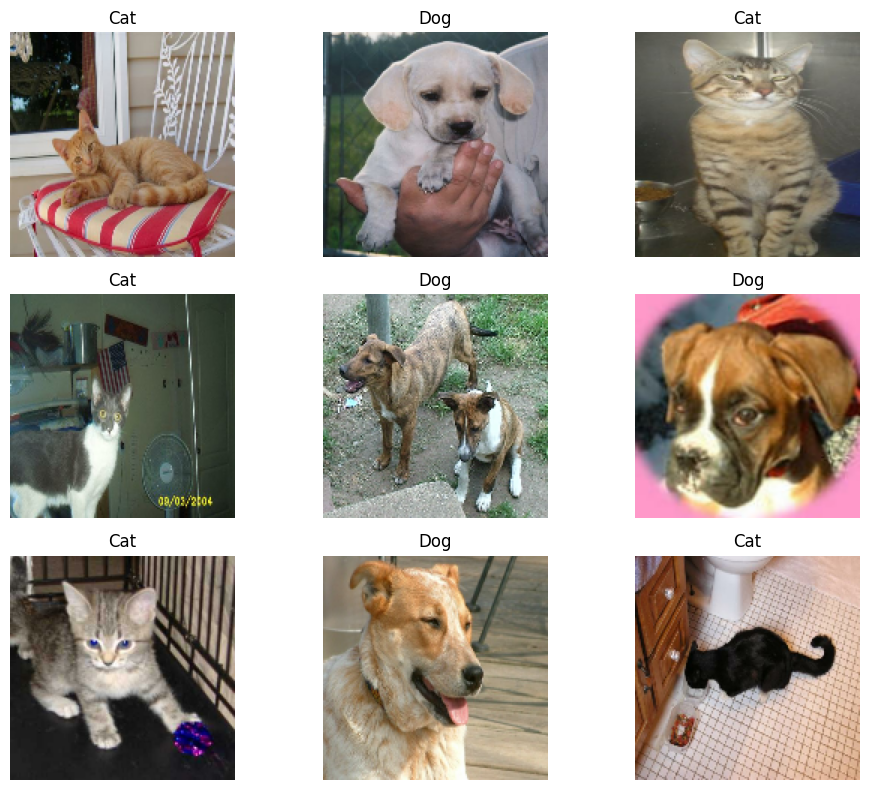

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = "Dog" if labels[i].numpy()[0] == 1 else "Cat"
        plt.title(label)

        plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
model = tf.keras.Sequential([

    # Images ko 0-1 range mein convert karega
    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),

    # First CNN layer
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Second CNN layer
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Third CNN layer
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(128, activation="relu"),

    # Reduce overfitting
    tf.keras.layers.Dropout(0.5),

    # Final output: Cat or Dog
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [20]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/10
268/625 ━━━━━━━━━━━━━━━━━━━━ 7:51 1s/step - accuracy: 0.6608 - loss: 0.6145

InvalidArgumentError: Graph execution error:

Detected at node decode_image/DecodeImage defined at (most recent call last):
<stack traces unavailable>
Input size should match (header_size + row_size * abs_height) but they differ by 2
	 [[{{node decode_image/DecodeImage}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_2305]

In [21]:
import os
import tensorflow as tf

folders = ["PetImages/Cat", "PetImages/Dog"]

bad_images = []

for folder in folders:
    for filename in os.listdir(folder):
        filepath = os.path.join(folder, filename)

        try:
            image_bytes = tf.io.read_file(filepath)
            image = tf.io.decode_image(
                image_bytes,
                channels=3,
                expand_animations=False
            )

            # Make sure image has valid dimensions
            if image.shape[0] is None or image.shape[1] is None:
                raise ValueError("Invalid image dimensions")

        except Exception as e:
            bad_images.append(filepath)

print("Problematic images found:", len(bad_images))

for filepath in bad_images:
    print("Removing:", filepath)
    os.remove(filepath)

print("Cleanup complete!")

Problematic images found: 7
Removing: PetImages/Cat/4351.jpg
Removing: PetImages/Cat/10404.jpg
Removing: PetImages/Dog/9500.jpg
Removing: PetImages/Dog/11912.jpg
Removing: PetImages/Dog/11233.jpg
Removing: PetImages/Dog/2494.jpg
Removing: PetImages/Dog/2317.jpg
Cleanup complete!


In [22]:
print("Cat images:", len(os.listdir("PetImages/Cat")))
print("Dog images:", len(os.listdir("PetImages/Dog")))

Cat images: 12497
Dog images: 12494


In [23]:
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

print("Classes:", train_dataset.class_names)


Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.
Classes: ['Cat', 'Dog']


In [24]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.7381 - loss: 0.5231 - val_accuracy: 0.7905 - val_loss: 0.4630
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 892s 1s/step - accuracy: 0.7942 - loss: 0.4444 - val_accuracy: 0.8193 - val_loss: 0.4033
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 904s 1s/step - accuracy: 0.8328 - loss: 0.3752 - val_accuracy: 0.8329 - val_loss: 0.3833
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 896s 1s/step - accuracy: 0.8670 - loss: 0.3141 - val_accuracy: 0.8385 - val_loss: 0.3780
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 894s 1s/step - accuracy: 0.8960 - loss: 0.2492 - val_accuracy: 0.8577 - val_loss: 0.3582
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 896s 1s/step - accuracy: 0.9162 - loss: 0.2024 - val_accuracy: 0.8465 - val_loss: 0.3888
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 873s 1s/step - accuracy: 0.9396 - loss: 0.1505 - val_accuracy: 0.8591 - val_loss: 0.3931
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 925s 1s/step - accuracy: 0.9518 - loss: 0.1268 - val_accu

In [25]:
# Evaluate model on test dataset

test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 393ms/step - accuracy: 0.8557 - loss: 0.5332
Test Loss: 0.533196747303009
Test Accuracy: 0.8557422757148743


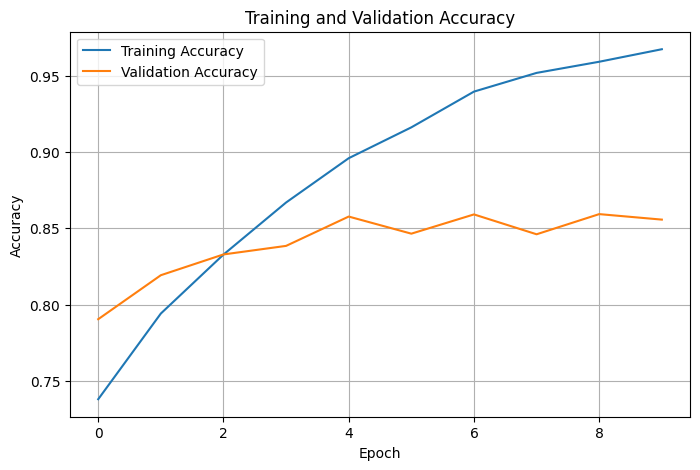

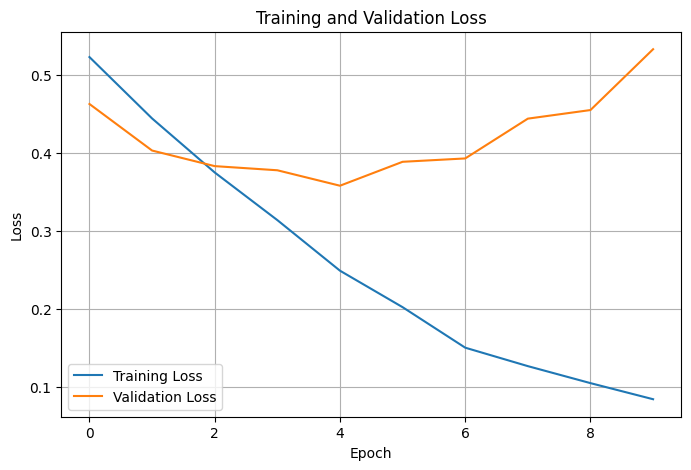

In [26]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.savefig("accuracy_graph.png")
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.savefig("loss_graph.png")
plt.show()

Confusion Matrix:
[[2072  370]
 [ 351 2205]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.86      0.85      0.85      2442
         Dog       0.86      0.86      0.86      2556

    accuracy                           0.86      4998
   macro avg       0.86      0.86      0.86      4998
weighted avg       0.86      0.86      0.86      4998



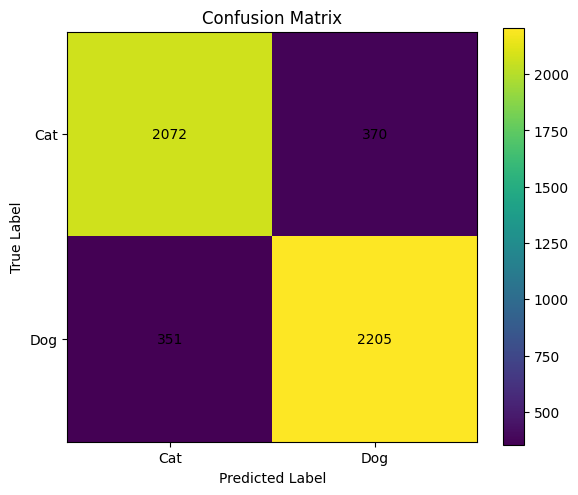

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Get actual labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

# Plot confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


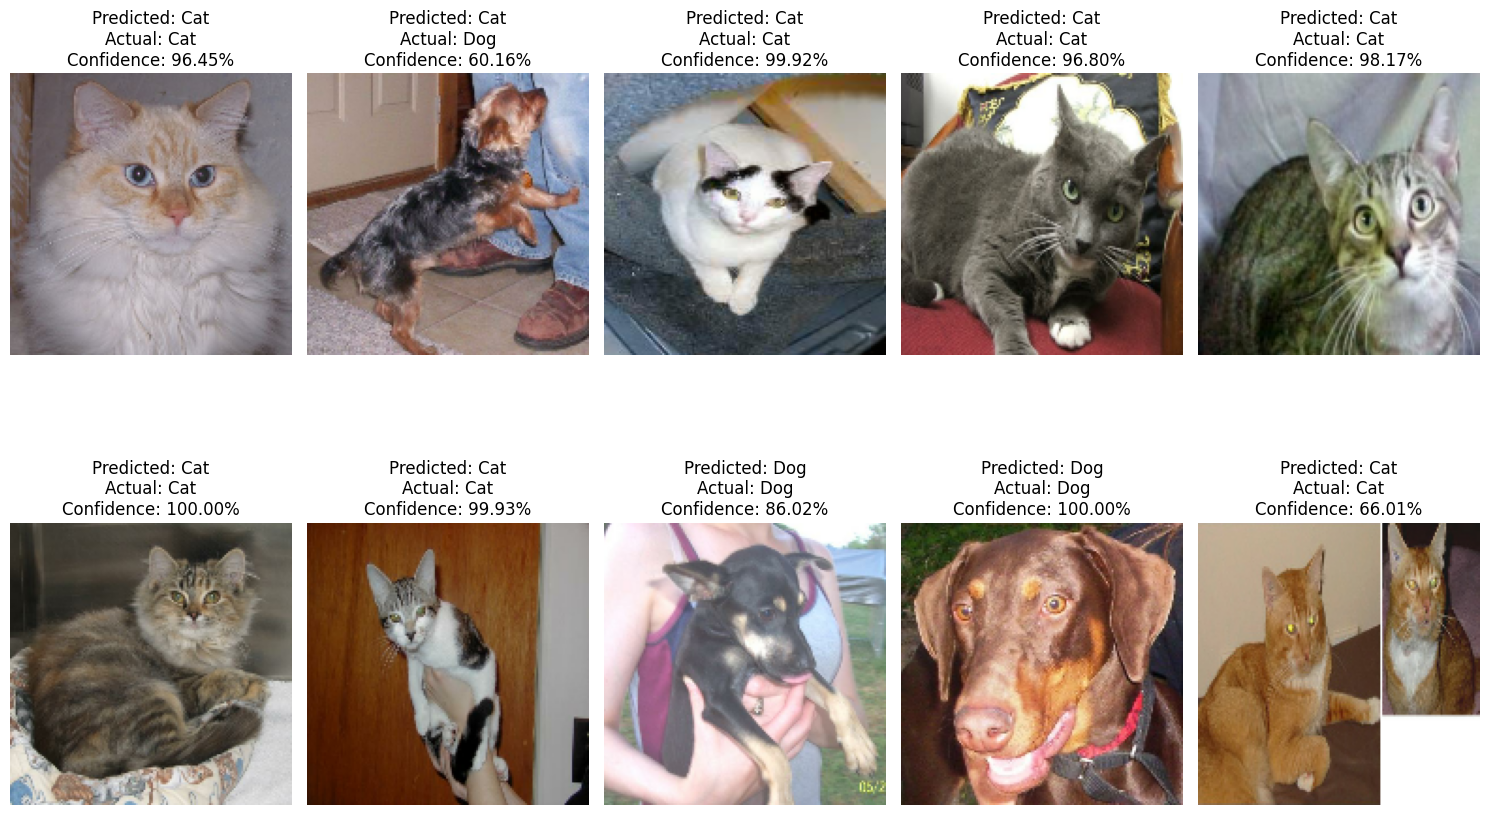

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of test images
for images, labels in test_dataset.take(1):

    predictions = model.predict(images, verbose=0)

    plt.figure(figsize=(15, 10))

    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)

        # Show image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Ground truth
        true_label = "Dog" if labels[i].numpy() == 1 else "Cat"

        # Prediction
        probability = predictions[i][0]
        predicted_label = "Dog" if probability >= 0.5 else "Cat"

        confidence = probability if probability >= 0.5 else 1 - probability

        plt.title(
            f"Predicted: {predicted_label}\n"
            f"Actual: {true_label}\n"
            f"Confidence: {confidence:.2%}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.savefig("10_sample_predictions.png")
    plt.show()

In [29]:
# Save the trained model

model.save("cats_vs_dogs_model.keras")

print("Model saved successfully!")

Model saved successfully!
